<a href="https://colab.research.google.com/github/Mohamedashraf2005/amazon_reviews_sentiment/blob/main/notebook/Amazon_Fine_Food_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard Library Imports
import pickle
import re
import string

# Third-Party Library Imports
from google.colab import drive, files
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
import xgboost as xgb

In [ ]:
nltk.download('punkt')  # For word_tokenize
nltk.download('stopwords')  # For stopwords
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os

def find_file(name, path):
    for root, dirs, files in os.walk(path):
        if name in files:
            return os.path.join(root, name)
    return None

real_path = find_file('Reviews.csv', '/content/drive/MyDrive')

if real_path:
    print(f" {real_path}")
else:
    print("not found")
df = pd.read_csv(real_path)

df.head()

 /content/drive/MyDrive/dataset/Reviews.csv


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.shape

In [ ]:
df.duplicated().sum()

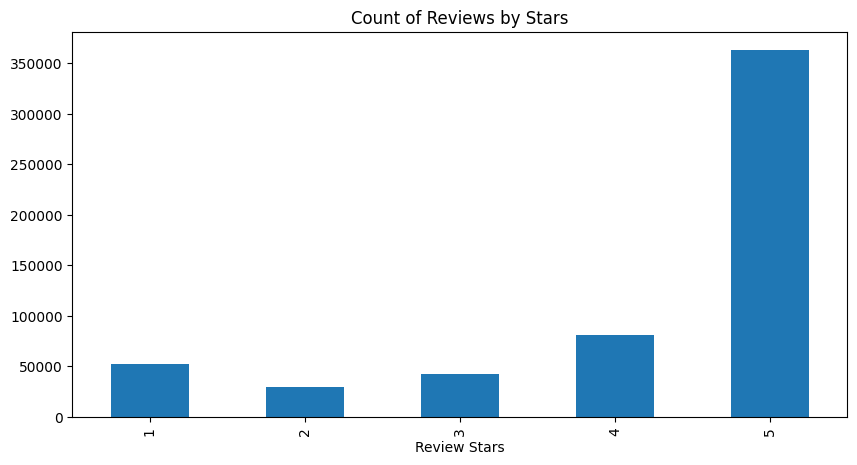

In [ ]:

ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))

ax.set_xlabel('Review Stars')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


#Data Cleaning

### Handle nulls

In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [ ]:
df.shape

(568401, 10)

### Handle duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df_copy = df.copy()

df = df[['Text', 'Summary', 'Score']]
df = df.drop_duplicates(subset=['Text'], keep='first')
df.head()

In [ ]:
df.shape

(568401, 3)

In [ ]:
df.duplicated().sum()

#Normalize text


### lowercasing

In [ ]:
def cleaning(text):



    text = re.sub(r'https?:\/\/\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)
    text=re.sub(r'<.*?>',' ',text)
    text=text.lower()
    text = text.split()
    text = ' '.join(text)
    return text



In [ ]:
df['cleaning']=df['Text'].apply(cleaning)

### punctuation removal

In [ ]:
import string
punc=string.punctuation
def remove_punc(text):
    return text.translate(str.maketrans('','',punc))


In [ ]:
df['Remove_punc']=df['cleaning'].apply(remove_punc)

In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...


### Data Cleaning and Preparation

Before applying any modeling techniques, several data cleaning steps were performed to ensure data quality and consistency:

- **Handling Missing Values:**  
  Rows with null or missing values were removed to avoid introducing noise or bias into the model.

- **Removing Duplicates:**  
  Duplicate records were identified and removed to prevent data leakage and ensure that the model does not learn repeated patterns.

- **Text Normalization:**  
  The text data was normalized by:
  - Converting all text to lowercase  
  - Removing punctuation and special characters  
  - Eliminating unnecessary whitespace  

- **Irrelevant Data Removal:**  
  Any non-informative or irrelevant content (such as symbols, extra characters, or noisy text) was cleaned to improve the overall quality of the dataset.

- **Final Cleaning Adjustments:**  
  Additional preprocessing steps were applied as needed to ensure the text is in a consistent and model-ready format.

These steps helped in creating a clean and structured dataset, leading to more reliable and accurate model performance.

# Preprocessing

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### word tokenization

In [ ]:
### word tokenization
from nltk.tokenize import word_tokenize
df['tokenized']=df['cleaning'].apply(word_tokenize)

In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc,tokenized
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ..."
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,..."
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro..."
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr..."
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, ., there, ..."


### Stopword removal

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

important_words = {
    'not', 'no', 'nor', 'never',
    'very', 'too', 'so',
    'but', 'however'
}

custom_stopwords = stop_words - important_words

def remove_stopWords(words):
    return [word for word in words if word.lower() not in custom_stopwords]

In [ ]:
df['Nostopword_text']=df['tokenized'].apply(remove_stopWords)

In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc,tokenized,Nostopword_text
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...","[bought, several, vitality, canned, dog, food,..."
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...","[product, arrived, labeled, jumbo, salted, pea..."
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...","[confection, around, centuries, ., light, ,, p..."
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...","[looking, secret, ingredient, robitussin, beli..."
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, ., there, ...","[great, taffy, great, price, ., wide, assortme..."


### Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
def lemmatizer_word(text):
 lemmas=[lemmatizer.lemmatize(word,pos='v') for word in text  ]
 return lemmas
df['lemmatizer_text']=df['Nostopword_text'].apply(lemmatizer_word)


In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc,tokenized,Nostopword_text,lemmatizer_text
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...","[bought, several, vitality, canned, dog, food,...","[buy, several, vitality, can, dog, food, produ..."
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...","[product, arrived, labeled, jumbo, salted, pea...","[product, arrive, label, jumbo, salt, peanuts,..."
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...","[confection, around, centuries, ., light, ,, p...","[confection, around, centuries, ., light, ,, p..."
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...","[looking, secret, ingredient, robitussin, beli...","[look, secret, ingredient, robitussin, believe..."
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, ., there, ...","[great, taffy, great, price, ., wide, assortme...","[great, taffy, great, price, ., wide, assortme..."


In [ ]:
df['clean_text'] = df['lemmatizer_text'].apply(lambda tokens: " ".join(tokens))


In [ ]:
for text in df['Text'][3000:3005]:
    print(text)
    print('-' * 40)

I am very pleased with this product. I almost did not buy them because they looked green on my computer, but when I received them they were the normal tan color that most of them are.
----------------------------------------
This is the second time I have ordered this product.  I was happy enough the first time to place an order again.  Cookies were fine and delivery was very quick. Thank you.
----------------------------------------
Well packed. Few are broken but it is understandable. The cookies are tasty and the notes are interesting. My friends and I really enjoyed it! Thx!
----------------------------------------
Great Product, fast shipment,the food product tasted great. none of the fortune cookies where opened.  i would buy again from this seller!
----------------------------------------
I bought these as a gift for my sister, I was so excited to see that they arrived in great condition. My sister loved them!
----------------------------------------


In [ ]:
for text in df['clean_text'][3000:3005]:
    print(text)
    print('-' * 40)

very please product . almost not buy look green computer , but receive normal tan color .
----------------------------------------
second time order product . happy enough first time place order . cookies fine delivery very quick . thank .
----------------------------------------
well pack . break but understandable . cookies tasty note interest . friends really enjoy ! thx !
----------------------------------------
great product , fast shipment , food product taste great . none fortune cookies open . would buy seller !
----------------------------------------
buy gift sister , so excite see arrive great condition . sister love !
----------------------------------------


In [ ]:
text = " ".join(df['clean_text'])

In [ ]:
text

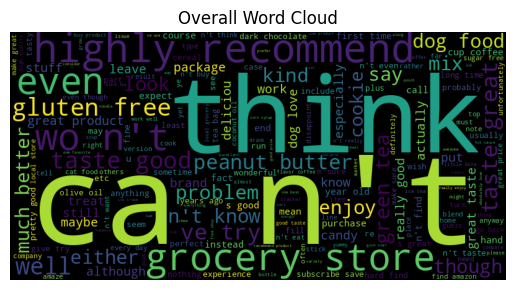

In [ ]:
# wordcloud = WordCloud(width=800, height=400).generate(text)

# plt.imshow(wordcloud)
# plt.axis('off')
# plt.title("Overall Word Cloud")
# plt.show()

In [ ]:
# df.drop(['cleaning','Remove_punc','tokenized','Nostopword_text','lemmatizer_text'],axis=1,inplace=True)

In [ ]:
df.head()

Text Structure and Linguistic Features

In [ ]:
import pandas as pd

required_columns = ['Time', 'Score', 'Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator']
if all(col in df.columns for col in required_columns):

    df['Time'] = pd.to_datetime(df['Time'], unit='s')
    df['ReviewYear'] = df['Time'].dt.year
    df['ReviewMonth'] = df['Time'].dt.month
    df['DayOfWeek'] = df['Time'].dt.dayofweek
else:
    print("Missing columns! Please check: ", df.columns)

Missing columns! Please check:  Index(['Text', 'Summary', 'Score', 'clean_text'], dtype='object')


In [ ]:
import string

df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))
df['avg_word_length'] = df['text_length'] / (df['word_count'] + 1)
df['avg_sentence_length'] = df['text_length'] / df['Text'].apply(lambda x: len(str(x).split('.')))

Punctuation and Typography Analysis

In [ ]:
df['punct_count'] = df['Text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
df['punct_percent'] = df['punct_count'] / (df['text_length'] + 1)
df['caps_ratio'] = df['Text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))

Emotional Intensity Indicators

In [ ]:
df['exclamation_count'] = df['Text'].str.count('!')
df['question_count'] = df['Text'].str.count('\?')

<>:2: SyntaxWarning: invalid escape sequence '\?'
<>:2: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_8051/2938067230.py:2: SyntaxWarning: invalid escape sequence '\?'
  df['question_count'] = df['Text'].str.count('\?')


Sentiment and Subjectivity (TextBlob)

In [ ]:
# from textblob import TextBlob

# sentiments = [TextBlob(str(text)).sentiment for text in df['Text']]

# df['polarity'] = [s.polarity for s in sentiments]
# df['subjectivity'] = [s.subjectivity for s in sentiments]

Vocabulary Diversity and Summary Context

In [ ]:
df['lexical_richness'] = df['Text'].apply(lambda x: len(set(str(x).split())) / len(str(x).split()) if len(str(x).split()) > 0 else 0)
df['summary_length'] = df['Summary'].str.len()
df['summary_ratio'] = df['summary_length'] / (df['text_length'] + 1)

Final Data Verification

In [ ]:
cols_to_show = ['text_length', 'avg_sentence_length', 'caps_ratio', 'polarity', 'lexical_richness']
print(df[cols_to_show].head())

   text_length  avg_sentence_length  caps_ratio  polarity  lexical_richness
0          263            65.750000    0.018939  0.450000          0.854167
1          190            31.666667    0.031414 -0.033333          0.903226
2          509            50.900000    0.041176  0.133571          0.744681
3          219            54.750000    0.045455  0.166667          0.878049
4          140            28.000000    0.028369  0.483333          0.814815


FastText Model Setup

In [ ]:
!pip install fasttext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.4 MB/s eta 0:00:00


In [ ]:
!pip install gensim
from gensim.models import FastText
from gensim.models.fasttext import load_facebook_model
import numpy as np
import pandas as pd

In [ ]:
# from gensim.models.fasttext import load_facebook_model
# import numpy as np
# import pandas as pd

# model = load_facebook_model('cc.en.300.bin')

# def get_fasttext_features(text):
#     words = str(text).lower().split()
#     vectors = [model.wv[word] for word in words if word in model.wv]
#     if not vectors:
#         return np.zeros(model.vector_size)
#     return np.mean(vectors, axis=0)

# fasttext_vectors = df['Text'].apply(get_fasttext_features)
# ft_matrix = np.vstack(fasttext_vectors.values)
# ft_df = pd.DataFrame(ft_matrix, index=df.index).add_prefix('ft_')

# df_final = pd.concat([
#     df[['lexical_richness', 'summary_ratio', 'polarity']],
#     ft_df
# ], axis=1)

In [ ]:
df.sample()

### Train Test

In [ ]:
X_text = df['lemmatizer_text'].str.split()
X_extra = df[extra_cols]
y = df['Score']

X_text_train, X_text_test, X_extra_train, X_extra_test, y_train, y_test = train_test_split(
    X_text, X_extra, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
cores = multiprocessing.cpu_count()
model = FastText(sentences=X_text_train, vector_size=100, window=5, min_count=2, workers=cores)
print(f"FastText model trained on {len(X_text_train)} training samples using {cores} cores.")

model.wv.fill_norms(force=True)

def vectorize_text(text_series, wv):
    return np.array([
        wv.get_mean_vector(text) if len(text) > 0 else np.zeros(wv.vector_size)
        for text in text_series
    ])

X_ft_train = vectorize_text(X_text_train, model.wv)
X_ft_test  = vectorize_text(X_text_test, model.wv)

X_train_final = np.hstack([X_ft_train, X_extra_train.values])
X_test_final  = np.hstack([X_ft_test, X_extra_test.values])


### Logistic Regression

In [ ]:
scaler = StandardScaler()
X_extra_train_scaled = scaler.fit_transform(X_extra_train)
X_extra_test_scaled  = scaler.transform(X_extra_test)

X_train_final = np.hstack([X_ft_train, X_extra_train_scaled])
X_test_final  = np.hstack([X_ft_test, X_extra_test_scaled])

lr_model = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced'
)

print("Training Logistic Regression with balanced weights...")
lr_model.fit(X_train_final, y_train)

y_pred = lr_model.predict(X_test_final)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
with open('logistic_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# model.save('my_ft.model')
files.download('logistic_model.pkl')
files.download('scaler.pkl')
files.download('my_ft.model')

print("Donnnnne")

### XGBOOST

In [ ]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    tree_method='hist'
)

print("Applying SMOTE to balance the dataset...")
smote = SMOTE(random_state=42)

# Resample the training data using the FINAL combined array
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train_xgb)

print("Training XGBoost on balanced data...")

xgb_model.fit(X_train_balanced, y_train_balanced)

y_pred_xgb_raw = xgb_model.predict(X_test_final)

y_pred_final = y_pred_xgb_raw + 1

print(f"\nXGBoost Accuracy: {accuracy_score(y_test, y_pred_final):.2f}")
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_final))

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("XGBoost model saved. You can predict by adding 1 to the model output.")

files.download('xgboost_model.pkl')
print("Download initiated.")

#### WHAT about hugging face  all-MiniLM-L6-v2

https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2